In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from google.colab import files

In [2]:
train_df=pd.read_csv("train_data.txt", sep=' ::: ', engine='python',names=['Year','Genre','Description'])
test_df=pd.read_csv("test_data.txt", sep=' ::: ',names=['Year','Description'], engine='python')
test_data_solution=pd.read_csv("test_data_solution.txt",names=['Year','Genre','Description'],sep=' ::: ', engine='python')

In [3]:
df=train_df

In [4]:
df.head()

,Year,Genre,Description
1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


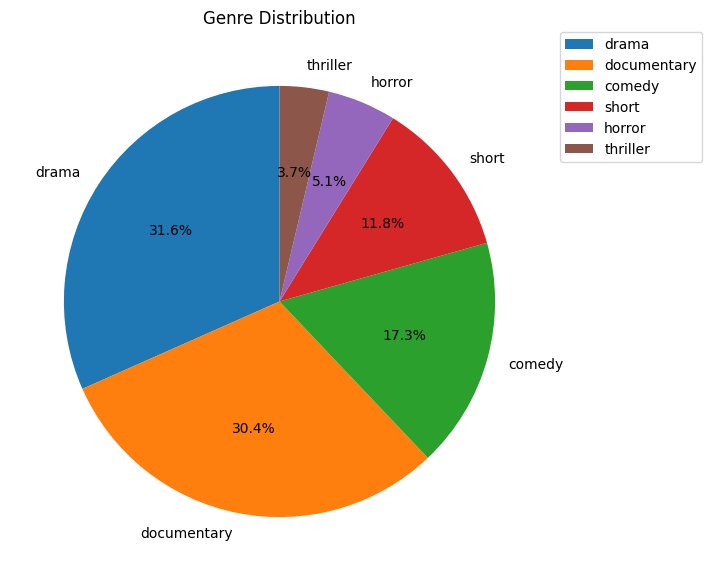

In [5]:
plt.figure(figsize=(7,7))
genre=df['Genre'].value_counts().head(6)
plt.pie(x=genre, labels=genre.index, autopct="%1.1f%%", startangle=90)
plt.title("Genre Distribution")
plt.savefig("genre_distribution.png")
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', borderaxespad=0.)
plt.show()

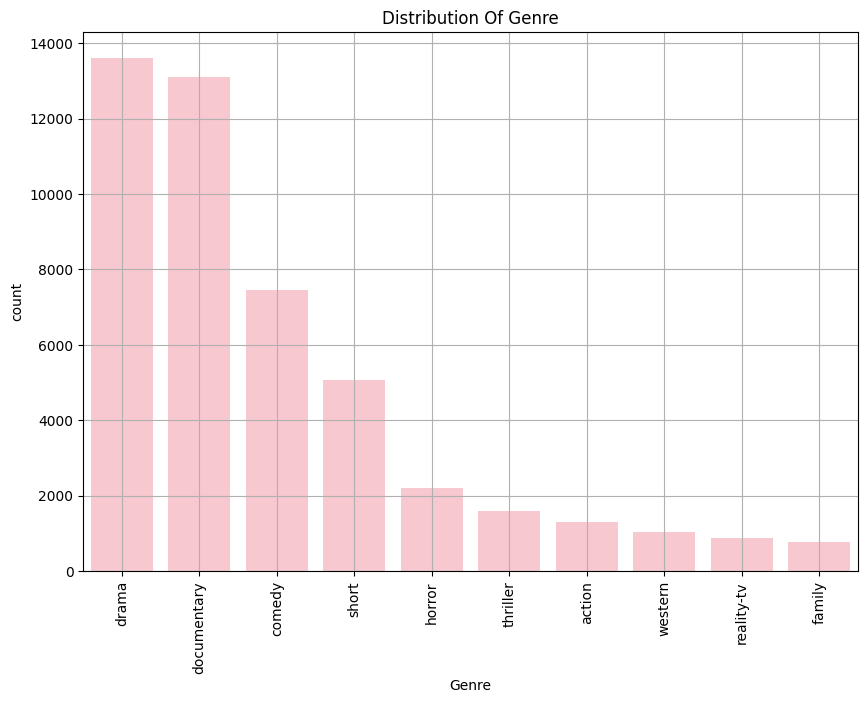

In [6]:
plt.figure(figsize=(10,7))
genre=df['Genre'].value_counts().head(10)
sns.barplot(x=genre.index,y=genre,color="pink")
plt.title("Distribution Of Genre")
plt.xticks(rotation=90)
plt.savefig("bar plot.png")
plt.grid()
plt.show()

In [7]:
df.columns

Index(['Year', 'Genre', 'Description'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54214 entries, 1 to 54214
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Year         54214 non-null  object
 1   Genre        54214 non-null  object
 2   Description  54214 non-null  object
dtypes: object(3)
memory usage: 1.7+ MB


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

STOP_WORDS = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [11]:
def preprocess(text):
  text=text.lower()
  text=text.translate(str.maketrans('','',string.punctuation))
  tokens=word_tokenize(text)
  tokens=[word for word in tokens if word not in STOP_WORDS]
  stemmer=PorterStemmer()
  tokens=[stemmer.stem(word) for word in tokens]
  return ' '.join(tokens)

In [12]:
df['Description'] = df['Description'].apply(preprocess)
df['Year']=df['Year'].apply(preprocess)

In [13]:
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()
df['Genre']=l.fit_transform(df['Genre'])

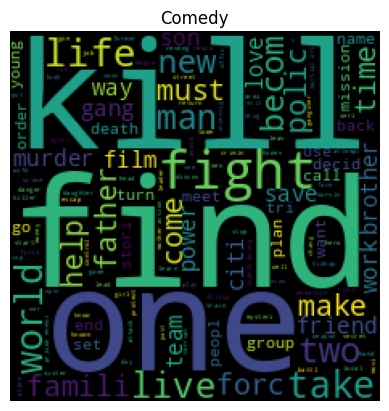

In [14]:
from wordcloud import WordCloud
comedy_words=' '.join(df[df['Genre']==0]['Description'])
wordcloud=WordCloud(height=230,width=230).generate(comedy_words)
plt.imshow(wordcloud)
plt.savefig("comedy_wordcloud.png")
plt.title("Comedy")
plt.axis("off")
plt.show()

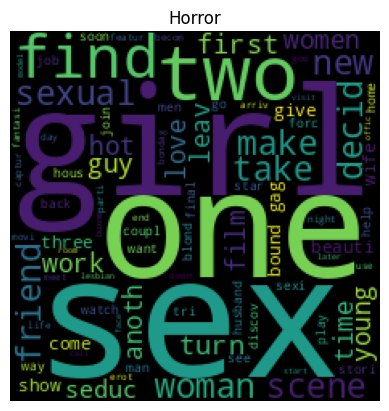

In [15]:
horror_words=''.join(df[df['Genre']==1]['Description'])
wordcloud=WordCloud(height=230,width=230).generate(horror_words)
plt.imshow(wordcloud)
plt.title("Horror")
plt.savefig("horror_wordcloud.png")
plt.axis("off")
plt.show()

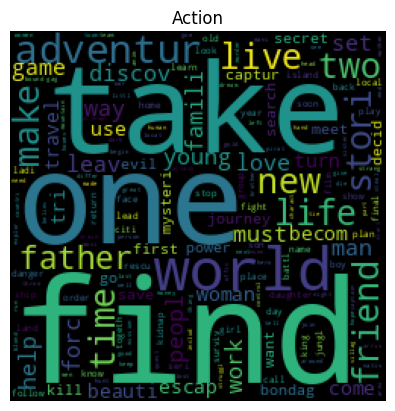

In [16]:
action_words=''.join(df[df['Genre']==2]['Description'])
wordcloud=WordCloud(height=244,width=248).generate(action_words)
plt.imshow(wordcloud)
plt.title("Action")
plt.axis("off")
plt.savefig("action_wordcloud.png")
plt.show()

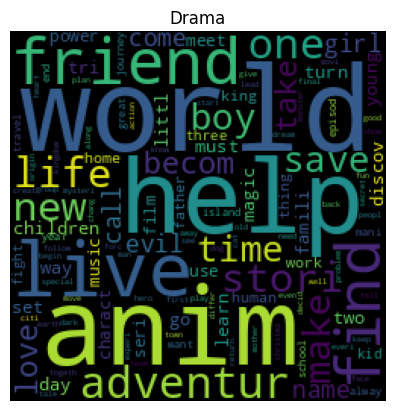

In [17]:
drama_words=''.join(df[df['Genre']==3]['Description'])
wordcloud=WordCloud(height=244,width=248).generate(drama_words)
plt.imshow(wordcloud)
plt.title("Drama")
plt.savefig("drama_wordcloud.png")
plt.axis("off")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
X = df['Description']
Y = df['Genre']
x_train_desc, x_test_desc, y_train, y_test = train_test_split(X, Y,test_size=0.2,random_state=42,stratify=Y)

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=50000,ngram_range=(1,2))
x_train_tfidf = tfidf.fit_transform(x_train_desc)
x_test_tfidf = tfidf.transform(x_test_desc)

In [23]:
from sklearn.linear_model import LogisticRegression

In [25]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train_tfidf,y_train)

LogisticRegression(max_iter=1000)

In [26]:
y_pred=model.predict(x_test_tfidf)

In [28]:
from sklearn.naive_bayes import MultinomialNB

In [29]:
n=MultinomialNB()
n.fit(x_train_tfidf,y_train)
y_pred_n=n.predict(x_test_tfidf)

In [30]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
print(f"Accuarcy:{accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(f1_score(y_test,y_pred,average='macro'))
print("For naive bayes:")
print(f"Accuarcy:{accuracy_score(y_test,y_pred_n)}")
print(classification_report(y_test,y_pred_n))
print(confusion_matrix(y_test,y_pred_n))
print(f1_score(y_test,y_pred_n,average='macro'))

Accuarcy:0.5826800700913032
              precision    recall  f1-score   support

           0       0.56      0.25      0.34       263
           1       0.83      0.25      0.39       118
           2       0.69      0.14      0.24       155
           3       0.54      0.07      0.12       100
           4       0.00      0.00      0.00        53
           5       0.52      0.58      0.55      1490
           6       0.33      0.02      0.04       101
           7       0.66      0.87      0.75      2619
           8       0.53      0.79      0.64      2723
           9       0.69      0.07      0.13       157
          10       0.00      0.00      0.00        65
          11       0.94      0.41      0.57        39
          12       0.00      0.00      0.00        49
          13       0.67      0.56      0.61       441
          14       0.67      0.38      0.49       146
          15       0.00      0.00      0.00        55
          16       0.00      0.00      0.00        64

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

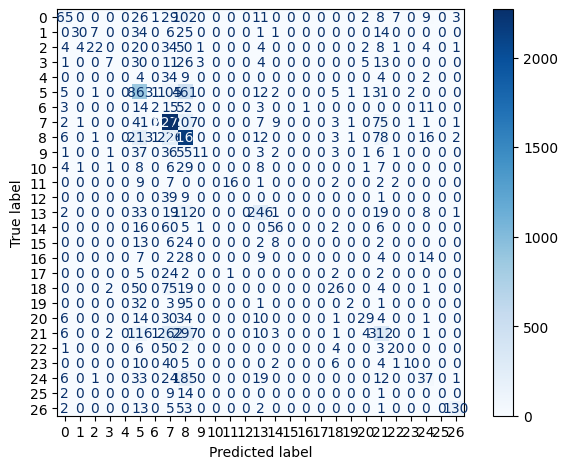

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred,labels=model.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.savefig("confusion_matrix.png")
plt.tight_layout()
plt.show()


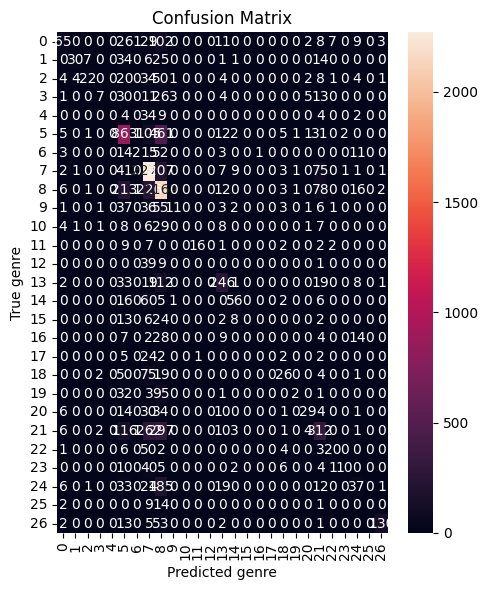

In [32]:
plt.figure(figsize=(5,6))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=model.classes_,yticklabels=model.classes_)
plt.xlabel("Predicted genre")
plt.ylabel("True genre")
plt.title("Confusion Matrix")
plt.savefig("heatmap.png")
plt.tight_layout()
plt.show()

In [33]:
from sklearn.svm import LinearSVC
svm=LinearSVC()
svm.fit(x_train_tfidf,y_train)
y_pred_svm=svm.predict(x_test_tfidf)

In [34]:
print(f"Accuarcy:{accuracy_score(y_test,y_pred_svm)}")
print(classification_report(y_test,y_pred_svm))
print(confusion_matrix(y_test,y_pred_svm))

Accuarcy:0.5807433367149313
              precision    recall  f1-score   support

           0       0.44      0.35      0.39       263
           1       0.70      0.47      0.56       118
           2       0.47      0.18      0.26       155
           3       0.38      0.11      0.17       100
           4       0.00      0.00      0.00        53
           5       0.52      0.59      0.56      1490
           6       0.35      0.08      0.13       101
           7       0.70      0.82      0.76      2619
           8       0.55      0.71      0.62      2723
           9       0.34      0.15      0.21       157
          10       0.20      0.03      0.05        65
          11       0.79      0.67      0.72        39
          12       0.33      0.04      0.07        49
          13       0.61      0.62      0.61       441
          14       0.62      0.51      0.56       146
          15       0.33      0.04      0.07        55
          16       0.10      0.02      0.03        64

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


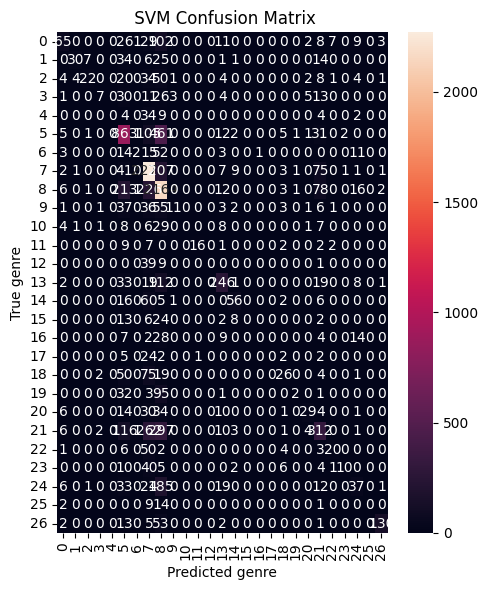

In [35]:
cm=confusion_matrix(y_test,y_pred,labels=svm.classes_)
plt.figure(figsize=(5,6))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=svm.classes_,yticklabels=svm.classes_)
plt.xlabel("Predicted genre")
plt.ylabel("True genre")
plt.title(" SVM Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig("heatmap.png")
plt.tight_layout()
plt.show()

In [40]:
movie_description="A detective investigatates a mysterious murder and discovers a dangerous criminal gang behind it."
cleaned_movie=preprocess(movie_description)
movie_tfidf=tfidf.transform([cleaned_movie])
prediction=model.predict(movie_tfidf)
predicted_genre=l.inverse_transform(prediction)
print("Predicted Genre:",predicted_genre[0])


Predicted Genre: crime


In [49]:
movie_description="Two childhood friends fall in love with each other"
cleaned_movie=preprocess(movie_description)
movie_tfidf=tfidf.transform([cleaned_movie])
prediction=model.predict(movie_tfidf)
predicted_genre=l.inverse_transform(prediction)
print("Predicted Genre:",predicted_genre[0])

Predicted Genre: drama


In [48]:
movie_description="Shinchan movie bungle in the jungle in the adventurous and majical jungle"
cleaned_movie=preprocess(movie_description)
movie_tfidf=tfidf.transform([cleaned_movie])
prediction=model.predict(movie_tfidf)
predicted_genre=l.inverse_transform(prediction)
print("Predicted Genre:",predicted_genre[0])

Predicted Genre: adventure


In [50]:
import joblib
joblib.dump(model,"model.pkl")
joblib.dump(tfidf,"tfidf.pkl")
joblib.dump(l,"label_encoder.pkl")

['label_encoder.pkl']